## Building a Perceptron

In this session we want to build a simple perceptron in order to understand how ANNs actually work. We also want to train the perceptron and visualize the manifold it approximates for the feature space.   

**0) Loading and Preparing Data**

We only import standard libraries since we want to build the perceptron from scratch:

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

<br>

Next, we import the **iris dataset**:

In [ ]:
from sklearn import datasets

In [ ]:
iris  = datasets.load_iris()
names = iris.target_names

Iris are a certain kind of orchids which can be classified based on their blossum leafs: the sepals and petals and their corresponding lengths and widths. Thus, we have four features and three different classes.
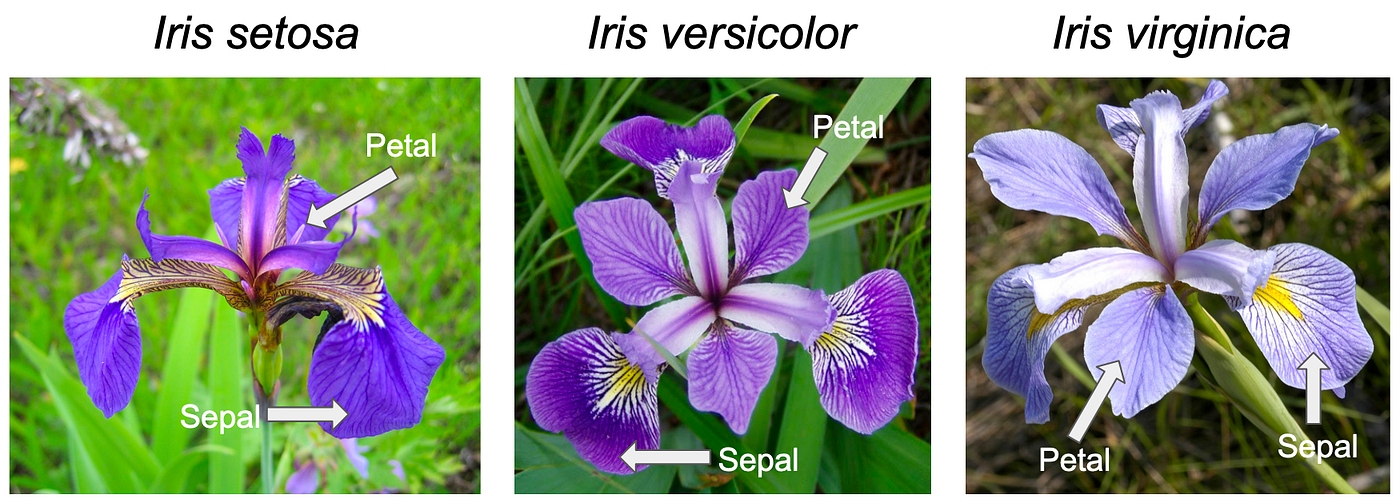

We want to keep it simple for now and start with **two classes only**: Setosa and "not Setosa"...

In [ ]:
mult  = [50,50,50]

Target = []
for n, m in zip(names, mult):
    Target.extend([n] * m)

indices = [i for i, x in enumerate(Target) if x == 'setosa']

Targetnum          = iris.target*0
Targetnum[indices] = 1

In [ ]:
print(Targetnum[:60])

...and also with two features for the purpose of visualization (for an actual analysis, we'd use all four features of course). 

In [ ]:
X    = iris.data
X2D  = X[:,1:3]

In [ ]:
print(X2D[:10])

In [ ]:
print(X[:10,:])

In [ ]:
print(Target[:10])

In [ ]:
#Try out this later. What is going to happen and why?
#Targetnum = iris.target
#print(Targetnum)

<br>

**1) Building the Neuron/Perceptron**

We learned in the lecture that the perceptron itself is just a linear model, where $I_i$ stands for the input channel (i. e. the different features, hence the columns of the data set) and $w_i$ are the corresponding weights: one for each input channel. In addition to that we add a bias $b$ which is equivalent to the intercept in a linear model. Therefore, the net output of a perceptron is:<br>
<br>
$net = \sum_i I_i\,w_i + b$<br>
<br>
If we have $N$ observations (i. e. $N$ rows), $I$ is a $N \times number\,of\,features$ matrix and $w_i$ is a vector of length $number\,of\,features$ (columns). Therefore, $net$ is a vector of lenght $N$.<br>
In order to introduce a non-linearity for a single perceptron (we will see later that a network of many perceptrons can solve non-linear problems too), we pass $net$ on to an activation function. Since we have a binary classification problem here (Setosa vs "not Setosa") we choose the sigmoid function (see logistic models):<br>
<br>
$Y = \frac{1}{1 + e^{-net}}$
<br>

Next, we need to compare the output $Y$ to the target $T$ and introduce an objective function<br>
<br>
$E = \frac{1}{2}\left(T - Y\right)^2$<br>
<br>
for which we need to **find a minimum by adjusting $w_i$ and $b$**.  

We learned in the lecture last week that the minimum can be found via gradient descent and therefore find<br>
<br>
$w_i(t+1) = w_i(t) - \alpha \frac{\partial E}{\partial w_i(t)}$<br>
$b(t+1) = b(t) - \alpha \frac{\partial E}{\partial b(t)}$<br>
<br>
where $\alpha$ is the learning rate.

Applying the chain rule to $E$ leads to (please check with pen & paper!)<br>
<br>
$w_i(t+1) = w_i(t) - \alpha\,(T-Y)\,(-1)\,Y(1 - Y)\,I_i$<br>
$b(t+1) = b(t) - \alpha\,(T-Y)\,(-1)\,Y(1 - Y)\,1$.<br>
<br>

Now we are ready to build the perceptron and to perform a few sanity checks:

In [ ]:
def Neuron1(Data, Target, alpha: float = 0.01):
    """    
    Data   :          the input matrix
    Target :          the target vector t for E = 0.5*(t - y)**2
    alpha  :          learning rate 
    """

    if len(Target.shape) == 1:
        Target = Target.reshape(len(Target), 1)

    [rows, cols] = Data.shape
 
    N = rows #N: Number of observations
    I = cols #I: Number of input channels

    #initializing weights incl bias:
    W     = np.random.normal(0, 1, (I + 1, 1))

    #adding bias column (see slides)
    bias  = np.ones((N,1))
    Input = np.hstack((Data, bias))

    #calculating prediction
    net   = np.dot(Input, W)    #net output
    Y     = 1/(1 + np.exp(-net))#activation here: sigmoid

    #target vs output
    Error  = Target - Y
    
    #backpropagation
    dY     = Y*(1 - Y)
    dE     = Error
    
    W[:-1] = W[:-1] - alpha*np.dot(-Input[:,:-1].transpose(), dY*dE) #for weights
    W[-1]  = W[-1]  - alpha*np.dot(-dY.transpose(), dE)              #for bias

    return W

<br>

Let us run the neuron for X and X2D and check the weights

In [ ]:
W = Neuron1(X2D, Targetnum)
print(W) 

In [ ]:
W = Neuron1(X, Targetnum)
print(W) 

<br>

Calling the percetron only once, performs exactly only one step $t=1$ to $t=2$ of gradient descent. Next, we want to see, if the weights converge and the error reduces if we run the code for many iterations. First we need to set the number of iterations as an input argument and then run a ```for``` loop within the neuron. Next, we add a plotting part at the end of the function to illustrate the changes of the weights, the bias and the error, hence the learning process.

In [ ]:
def Neuron2(Niter, Data, Target, alpha: float = 0.01):
    """
    Niter  :          number of iterations    
    Data   :          the input matrix
    Target :          the target vector t for E = 0.5*(t - y)**2
    alpha  :          learning rate   
    """
    if len(Target.shape) == 1:
        Target = Target.reshape(len(Target),1)
        
    [rows, cols] = Data.shape
 
    N = rows #N: Number of observations
    I = cols #I: Number of input channels

    #initializing weights incl bias:
    W     = np.random.normal(-1,1,(I + 1,1))

    #adding bias column (see slides)
    bias  = np.ones((N,1))
    Input = np.hstack((Data, bias))

    MSE   = np.zeros((Niter,1))    #monitoring E
    Wei   = np.zeros((Niter,I + 1))#monitoring weights and bias

    for n in range(Niter):

        #calculating prediction
        net   = np.dot(Input, W)    #net output
        Y     = 1/(1 + np.exp(-net))#activation here: sigmoid
    
        #target vs output
        Error  = Target - Y
        
        #backpropagation
        dY     = Y*(1 - Y)
        dE     = Error
        
        W[:-1] = W[:-1] - alpha*np.dot(-Input[:,:-1].transpose(), dY*dE) #for weights
        W[-1]  = W[-1]  - alpha*np.dot(-dY.transpose(), dE)              #for bias

        #saving results    
        MSE[n]   = sum(Error**2)/N
        Wei[n,:] = W.transpose()

    
########plotting#################################################################

    fig, axs = plt.subplots(3, 1)
    axs[0].plot(range(Niter), MSE, c = 'black', linewidth = 3)
    axs[0].set_title('MSE')
    axs[0].set_xlabel('iteration')
    axs[0].set_yscale('log')
    axs[1].plot(range(Niter), Wei, linewidth = 3)
    axs[1].set_title('weights')
    axs[1].set_xlabel('iteration')
    axs[2].stairs(Target[:,0], color = 'k', label = 'target')
    axs[2].stairs(Y[:,0], label = 'prediction', linewidth = 3)
    axs[2].set_ylabel('class')
    axs[2].legend()
    fig.tight_layout(pad = 1.0)
    plt.show()
    
    return Wei

In [ ]:
Wei = Neuron2(700, X2D, Targetnum) 

In [ ]:
Wei = Neuron2(5000, X, Targetnum)

We see that for most runs, the error reduces and the weights converge. But in some cases the neuron doesn't seem to find a good minimum. This is because we neither have implemented an adaptive learning rate, nor a momentum or any regularization.

<br>

We still want to understand the learning process in more detail. Run the function ```NeuronContour.py```. This function visualizes the discriminator the perceptron learns based on the input data (the training data set) and the activation function. Run the function ```NeuronContour.py``` for different numbers of iterations and explore how the discriminator emerges.

In [ ]:
def NeuronContour(Niter, Data, Target, alpha: float = 0.01):
    """
    Niter  :          number of iterations    
    Data   :          the input matrix
    Target :          the target vector t for E = 0.5*(t - y)**2
    alpha  :          learning rate
    """
    #creating meshgrid through the data range for illustration
    Ngrid = 100

    x1 = np.linspace(Data[:,0].min(), Data[:,0].max(), Ngrid)
    x2 = np.linspace(Data[:,1].min(), Data[:,1].max(), Ngrid)
    
    [xx1, xx2] = np.meshgrid(x1, x2)


    if len(Target.shape) == 1:
        Target = Target.reshape(len(Target),1)
        
    [rows, cols] = Data.shape
 
    N = rows #N: Number of observations
    I = cols #I: Number of input channels

    #initializing weights incl bias:
    W     = np.random.normal(-1,1,(I + 1,1))

    #adding bias column (see slides)
    bias  = np.ones((N,1))
    Input = np.hstack((Data, bias))


    for n in range(Niter):

        #calculating prediction
        net   = np.dot(Input, W)    #net output
        Y     = 1/(1 + np.exp(-net))#activation here: sigmoid
    
        #target vs output
        Error     = Target - Y
        
        #backpropagation
        dY     = Y*(1 - Y)
        dE     = Error
        
        W[:-1] = W[:-1] - alpha*np.dot(-Input[:,:-1].transpose(), dY*dE) #for weights
        W[-1]  = W[-1]  - alpha*np.dot(-dY.transpose(), dE)              #for bias



    
########plotting#################################################################
    XY        = np.c_[xx1.ravel(), xx2.ravel()]
    L         = XY.shape[0]
    Inputcont = np.hstack((XY, np.ones((L,1))))
    netcont   = np.dot(Inputcont, W)
    Ycont     = 1/(1 + np.exp(-netcont))
    Ycont     = Ycont[:,0:2].reshape(Ngrid,Ngrid)
    Y         = np.round(Y)
    
    IdxTrue0 = np.argwhere(Target == 0)
    IdxTrue1 = np.argwhere(Target == 1)
    
    IdxPred0 = np.argwhere(Y == 0)
    IdxPred1 = np.argwhere(Y == 1)

    CM = "Blues"
    
    plt.contourf(xx1, xx2, Ycont, cmap = CM, alpha = 0.3, levels = 100)
    plt.scatter(Data[IdxTrue0, 0], Data[IdxTrue0, 1], color = [255/256,69/256,0], marker = '.', label = 'actual class 0')
    plt.scatter(Data[IdxTrue1, 0], Data[IdxTrue1, 1], color = [46/256,139/256,87/256], marker = '.', label = 'actual class 1')
    plt.scatter(Data[IdxPred0, 0], Data[IdxPred0, 1], edgecolors = [255/256,69/256,0], marker = 'o', facecolors = 'none', label = 'prediced class 0')
    plt.scatter(Data[IdxPred1, 0], Data[IdxPred1, 1], edgecolors = [46/256,139/256,87/256], marker = 'o', facecolors = 'none', label = 'prediced class 1')
    plt.legend()
    plt.show()

<br>

In [ ]:
NeuronContour(3, X2D, Targetnum)

In [ ]:
NeuronContour(10, X2D, Targetnum)

In [ ]:
NeuronContour(100, X2D, Targetnum)

In [ ]:
NeuronContour(10000, X2D, Targetnum)